In [22]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [3]:
# set path

data_path = "/Users/franziskakoch/Documents/Uni/UHH/second_semester/LEX/clouds-aerosols-radiation/Data/"
processed_data_path = data_path + "CloudCamProcessed/"

In [4]:
# load data

cf = pd.read_csv(processed_data_path + "CAM1/combined_cloud_fraction_timeseries.csv")
cf.timestamp_utc = pd.to_datetime(cf.timestamp_utc)

In [5]:
cf["cloud_fraction_diff"] = cf["cloud_fraction_land"] - cf["cloud_fraction_sea"]
print(cf.cloud_fraction_diff)

0        0.1267
1        0.1024
2        0.1039
3        0.0671
4        0.0609
          ...  
11951   -0.0032
11952   -0.0034
11953   -0.0043
11954   -0.0055
11955   -0.0085
Name: cloud_fraction_diff, Length: 11956, dtype: float64


In [6]:
dates = [
    "2026-08-04", 
    "2026-08-05", 
    "2026-08-06", 
    "2026-08-07", 
    "2026-08-08", 
    "2026-08-09", 
    "2026-08-10", 
    "2026-08-11", 
    "2026-08-12",
    "2026-08-13",
    "2026-08-14",
    "2026-08-15",
    "2026-08-16",
    "2026-08-17",
    "2026-08-18"
    ]

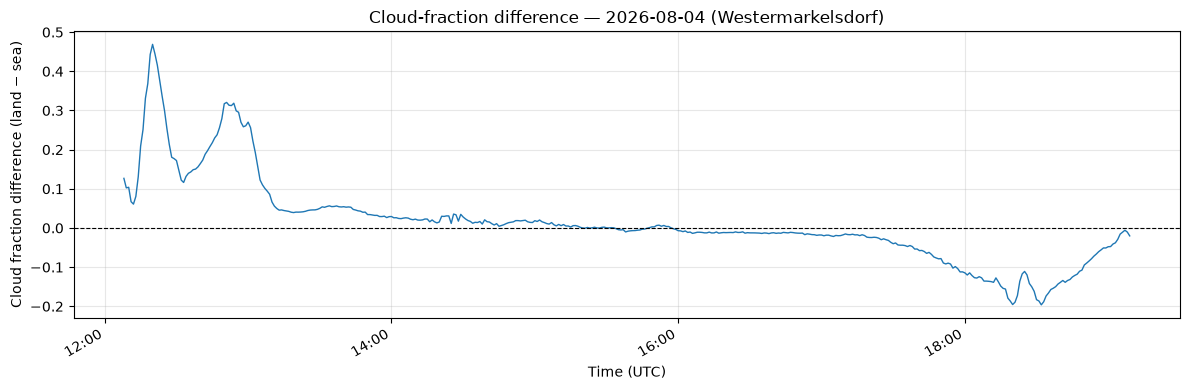

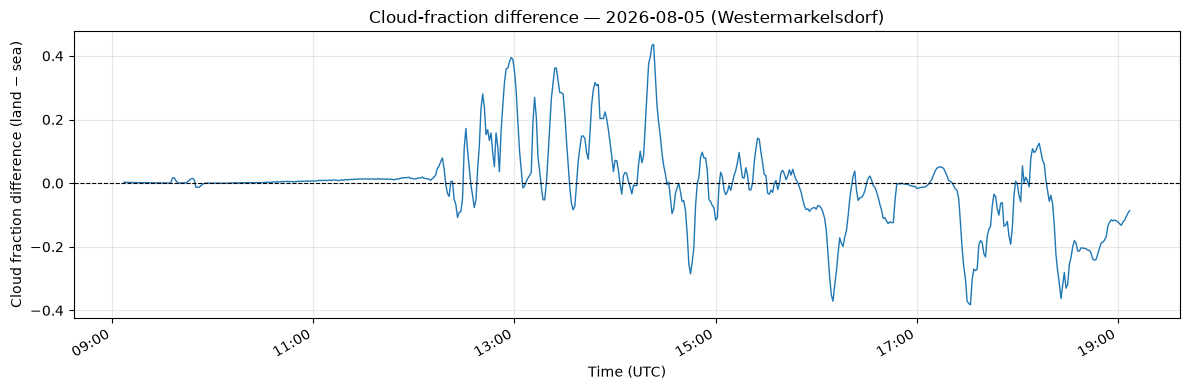

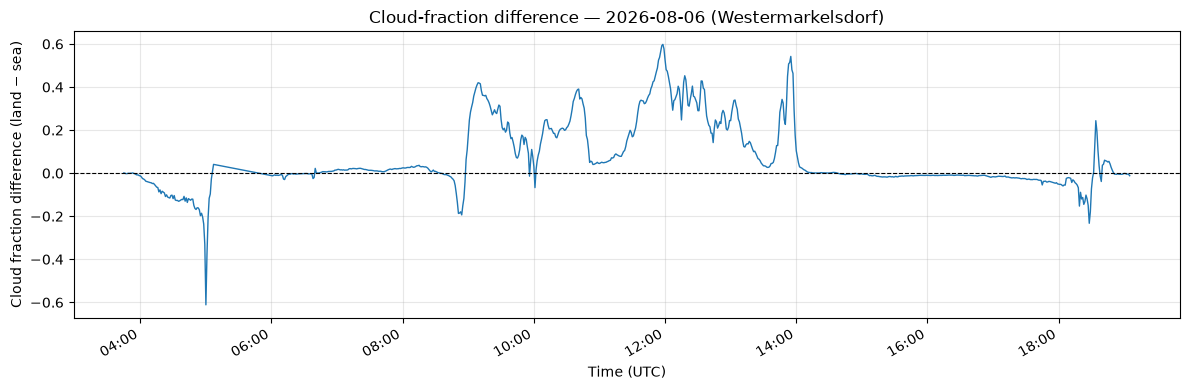

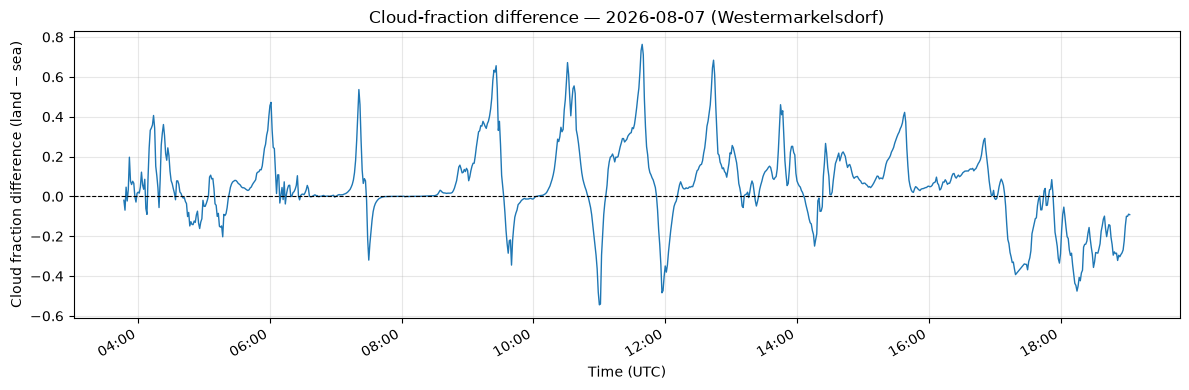

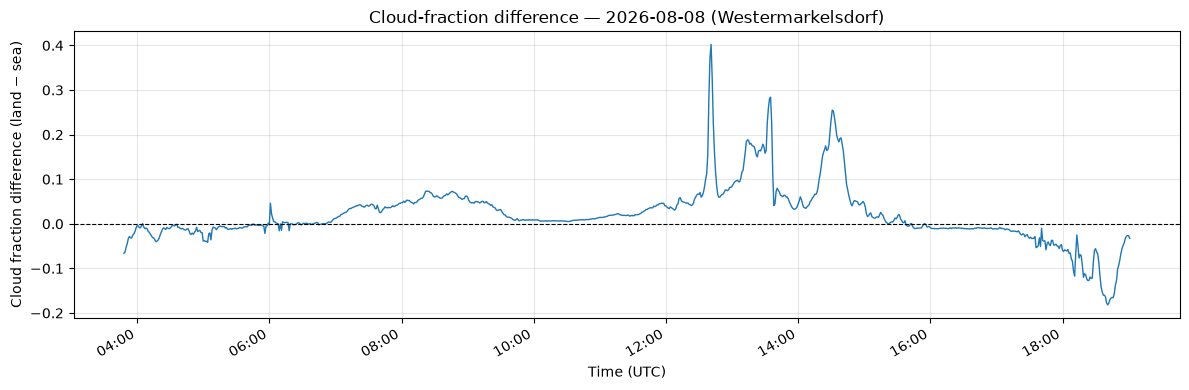

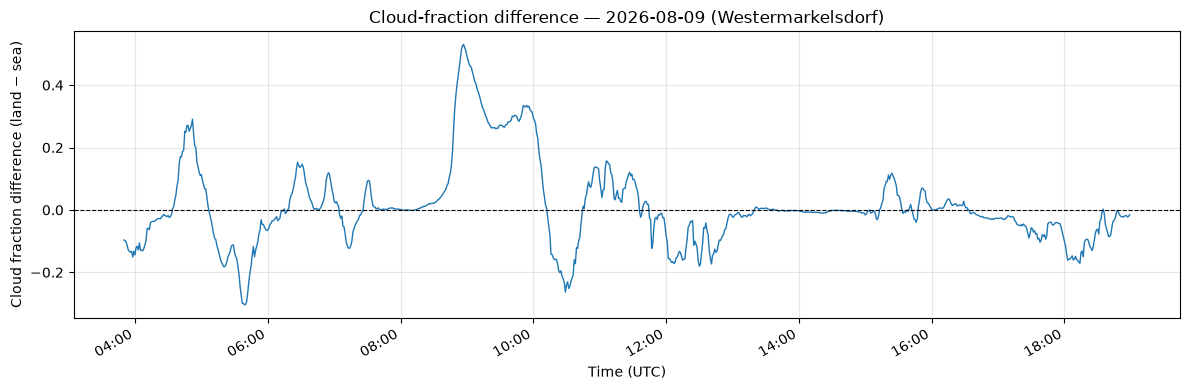

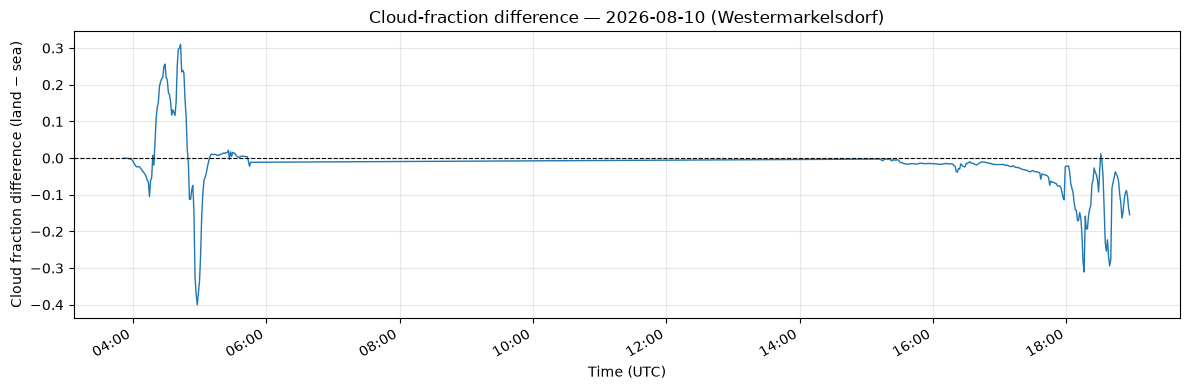

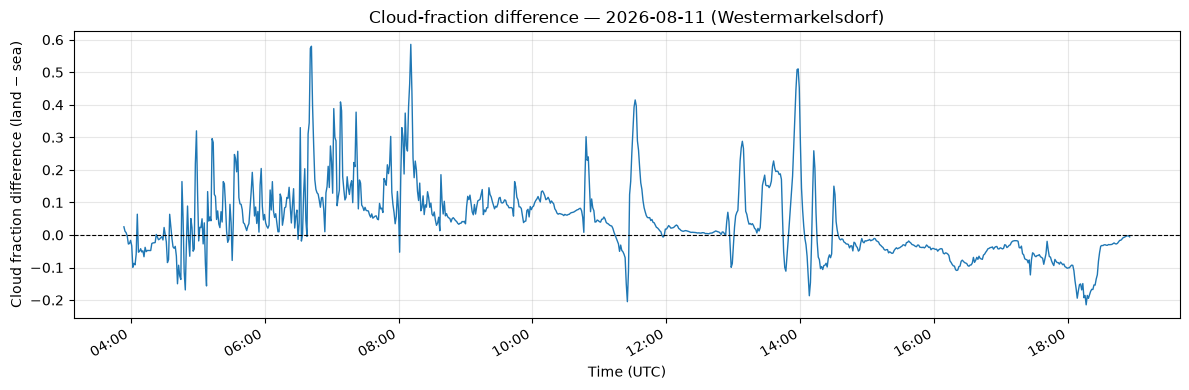

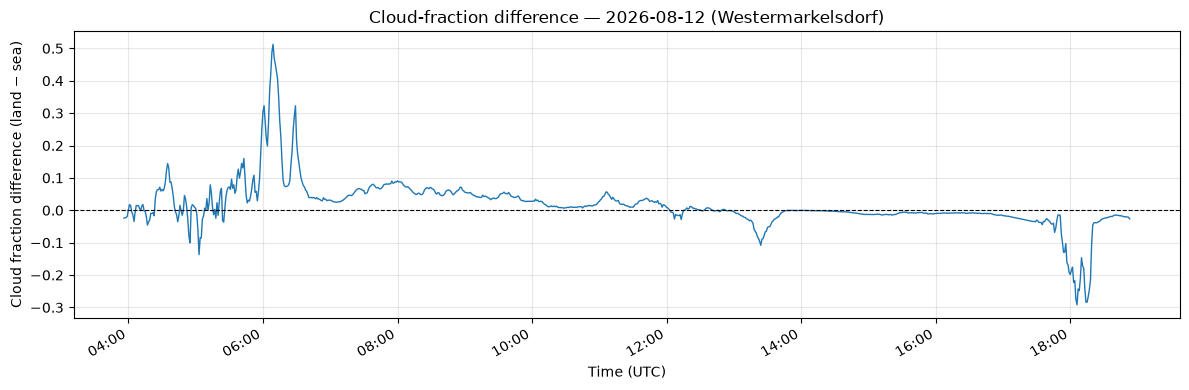

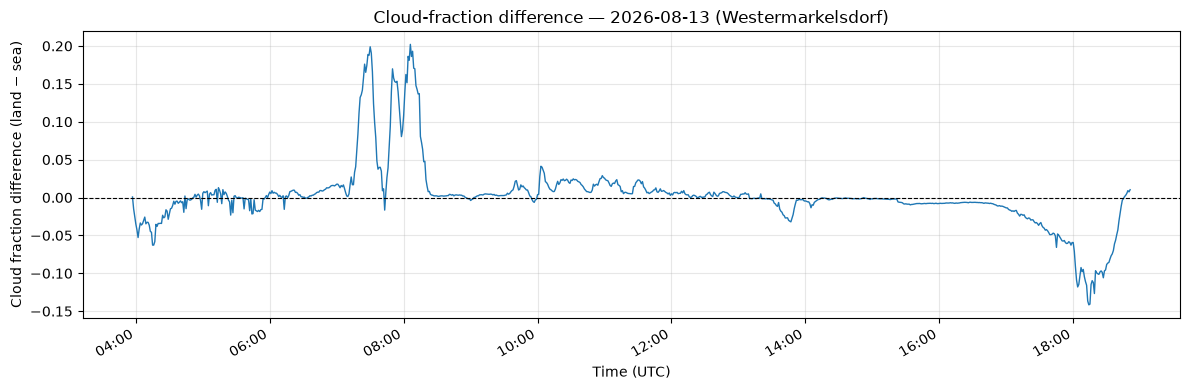

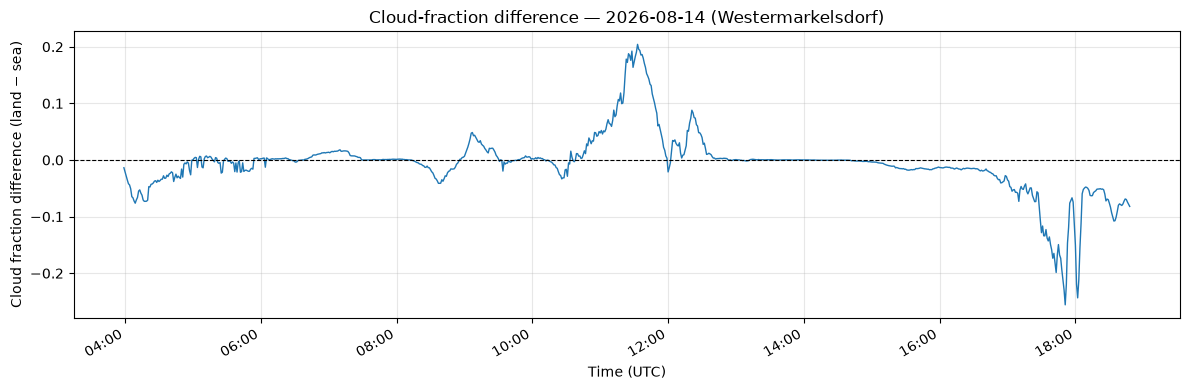

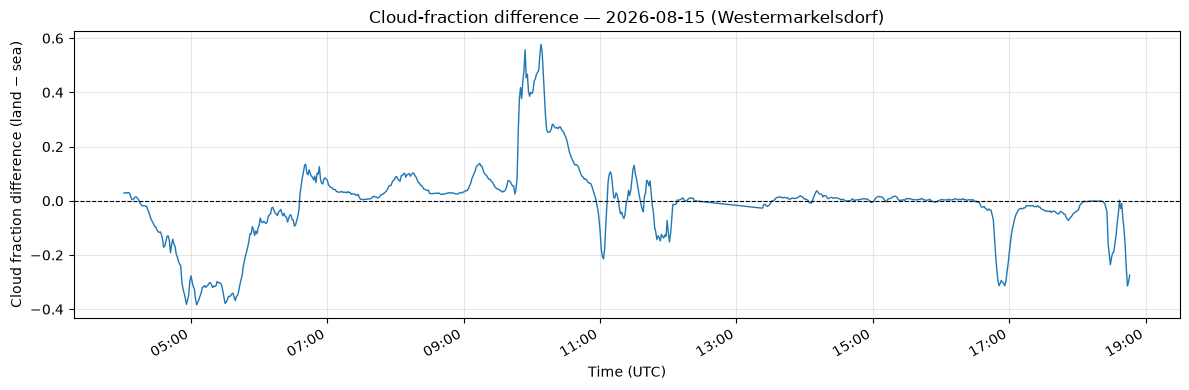

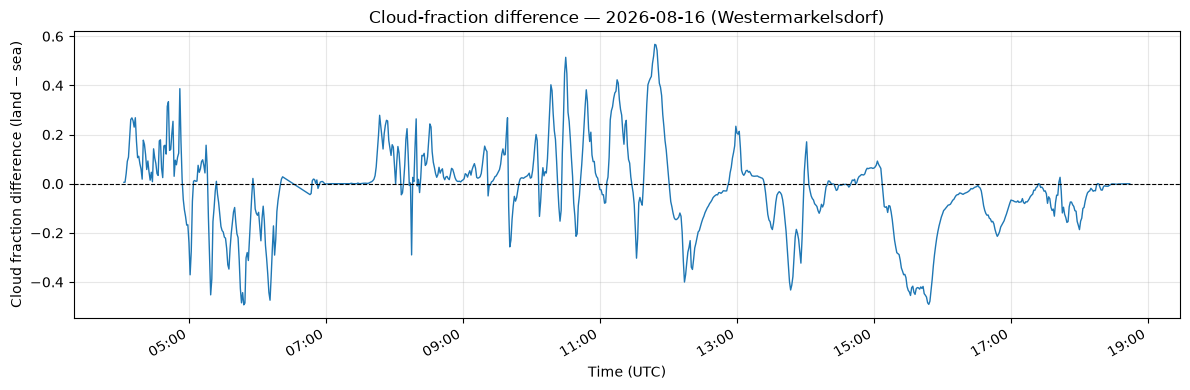

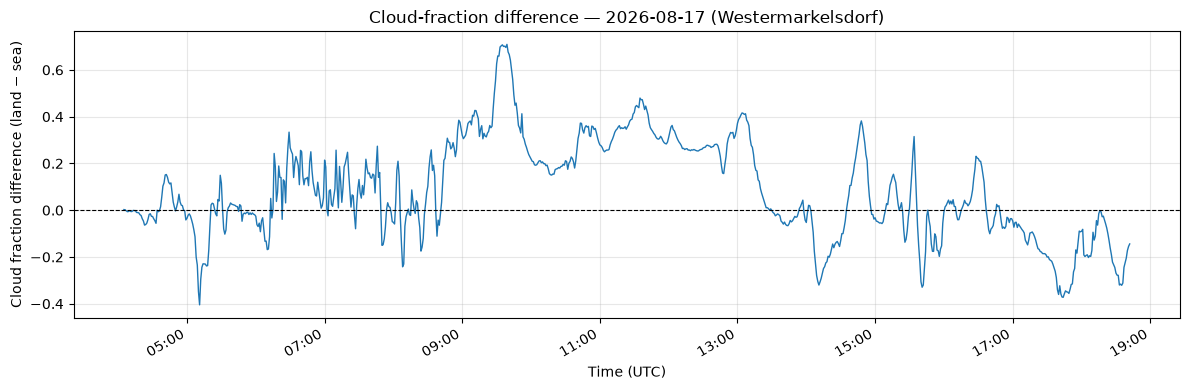

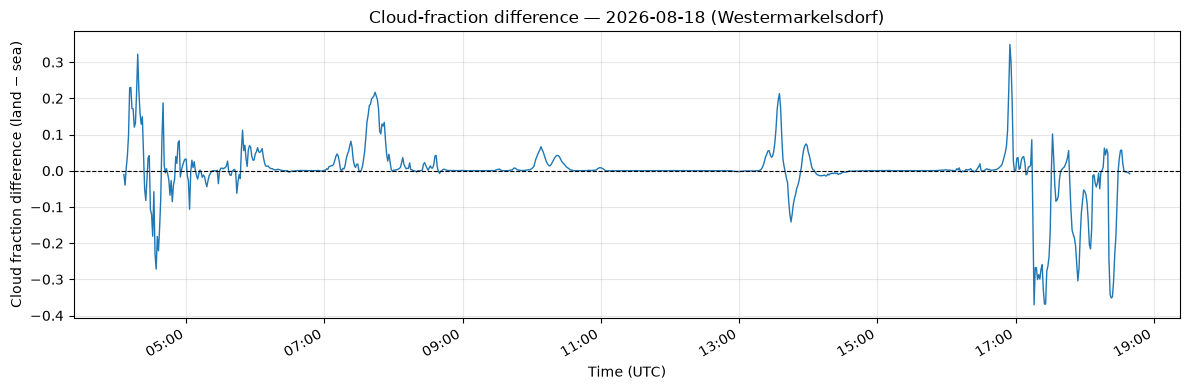

In [6]:
# plot cloud-fraction difference for each day
for date in dates:
    day_start = pd.Timestamp(date, tz="UTC")
    day_end = day_start + pd.Timedelta(days=1)
    day_data = cf.loc[
        (cf["timestamp_utc"] >= day_start)
        & (cf["timestamp_utc"] < day_end)
    ]

    if day_data.empty:
        print(f"No data available for {date}")
        continue

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(
        day_data["timestamp_utc"],
        day_data["cloud_fraction_diff"],
        linewidth=1,
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Cloud-fraction difference — {date} (Westermarkelsdorf)")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Cloud fraction difference (land − sea)")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()


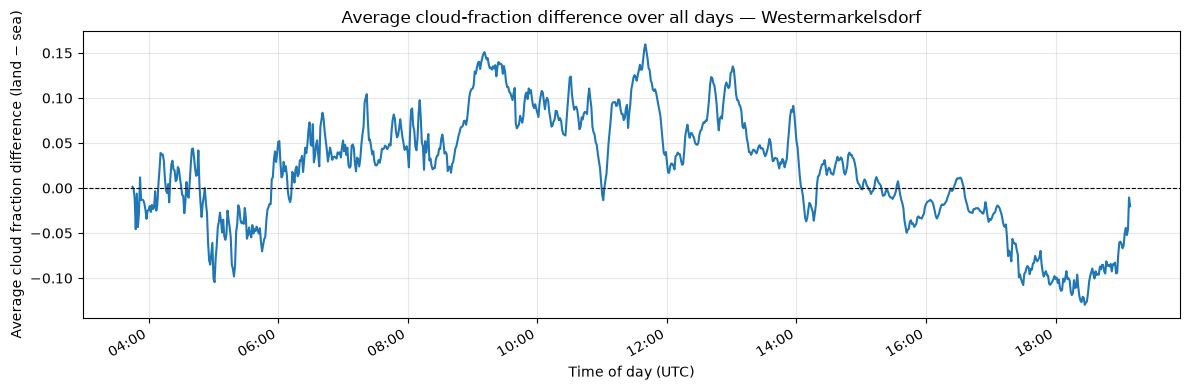

In [7]:
# average cloud-fraction difference over all days by time of day
cf["time_of_day_seconds"] = (
    cf["timestamp_utc"].dt.hour * 3600
    + cf["timestamp_utc"].dt.minute * 60
    + cf["timestamp_utc"].dt.second
)

average_diff = (
    cf.groupby("time_of_day_seconds", as_index=False)["cloud_fraction_diff"]
    .mean()
    .rename(columns={"cloud_fraction_diff": "average_cloud_fraction_diff"})
)
average_diff["time_utc"] = (
    pd.Timestamp("2000-01-01", tz="UTC")
    + pd.to_timedelta(average_diff["time_of_day_seconds"], unit="s")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    average_diff["time_utc"],
    average_diff["average_cloud_fraction_diff"],
    linewidth=1.5,
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Average cloud-fraction difference over all days — Westermarkelsdorf")
ax.set_xlabel("Time of day (UTC)")
ax.set_ylabel("Average cloud fraction difference (land − sea)")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


In [7]:
# Klausdorf - WKM2

cf2 = pd.read_csv(processed_data_path + "CAM2/combined_cloud_fraction_timeseries.csv")
cf2.timestamp_utc = pd.to_datetime(cf2.timestamp_utc)

In [8]:
cf2["cloud_fraction_diff"] = cf2["cloud_fraction_land"] - cf2["cloud_fraction_sea"]

In [9]:
dates2 = [ 
    "2026-08-10", 
    "2026-08-11", 
    "2026-08-12",
    "2026-08-13",
    "2026-08-14",
    "2026-08-15",
    "2026-08-16",
    "2026-08-17",
    "2026-08-18",
    "2026-08-19"
    ]

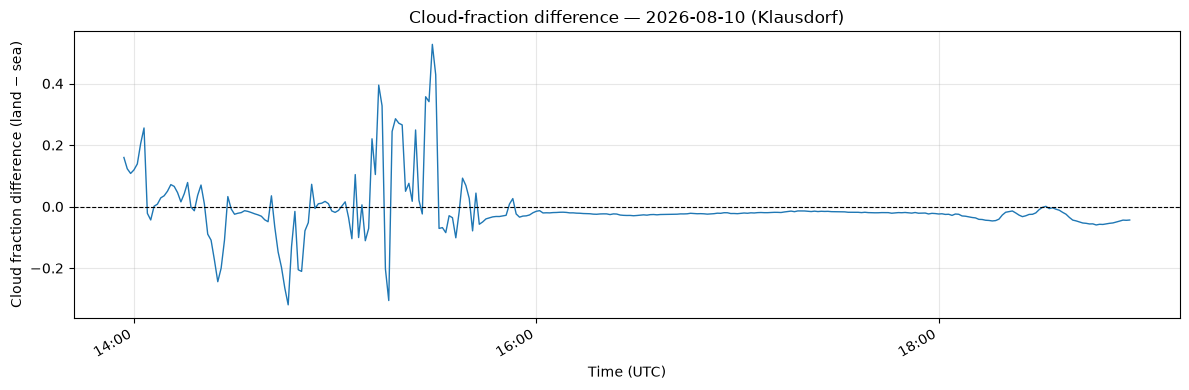

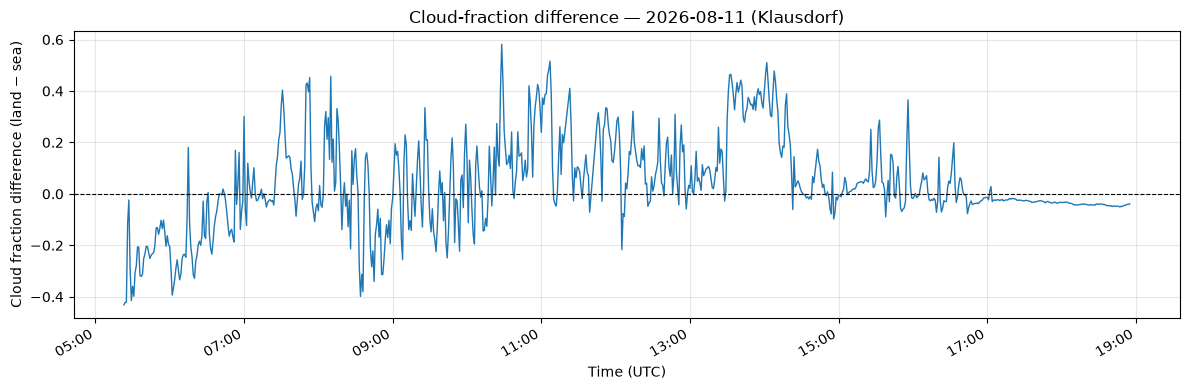

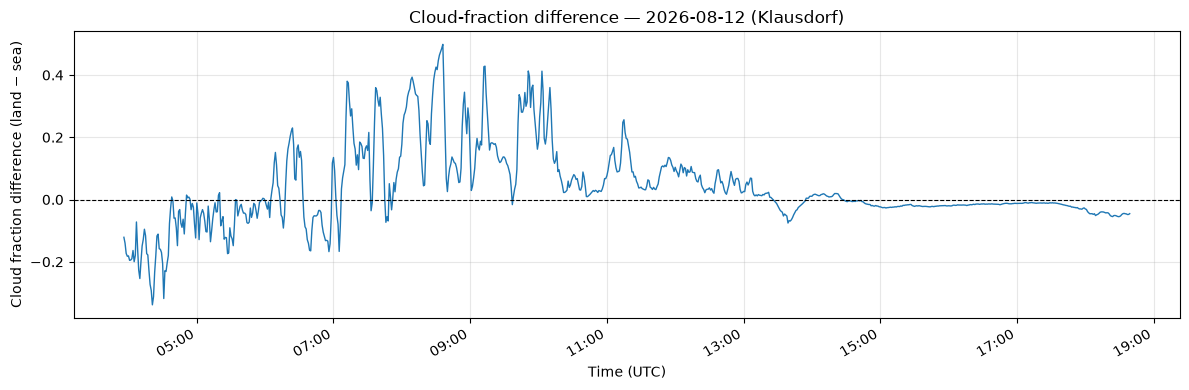

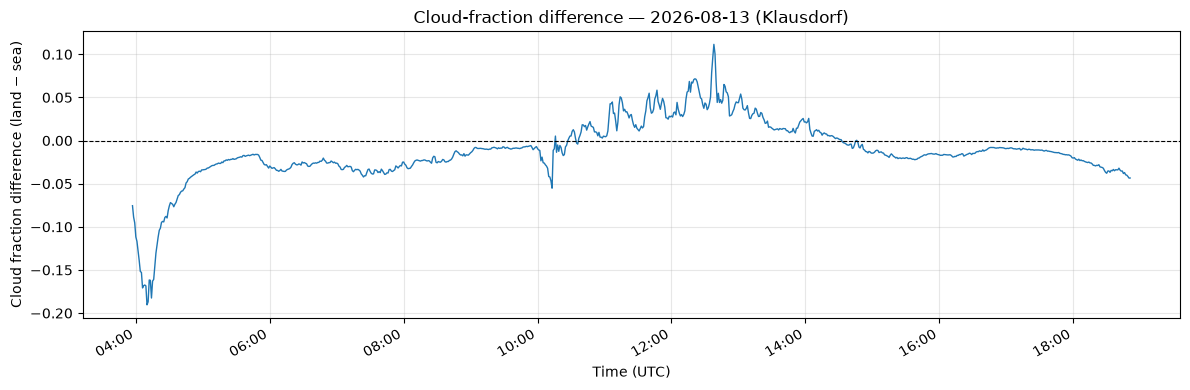

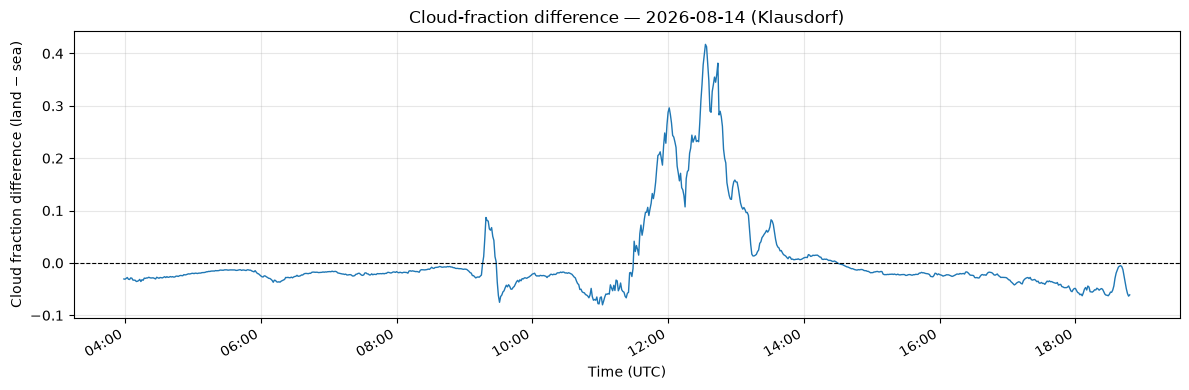

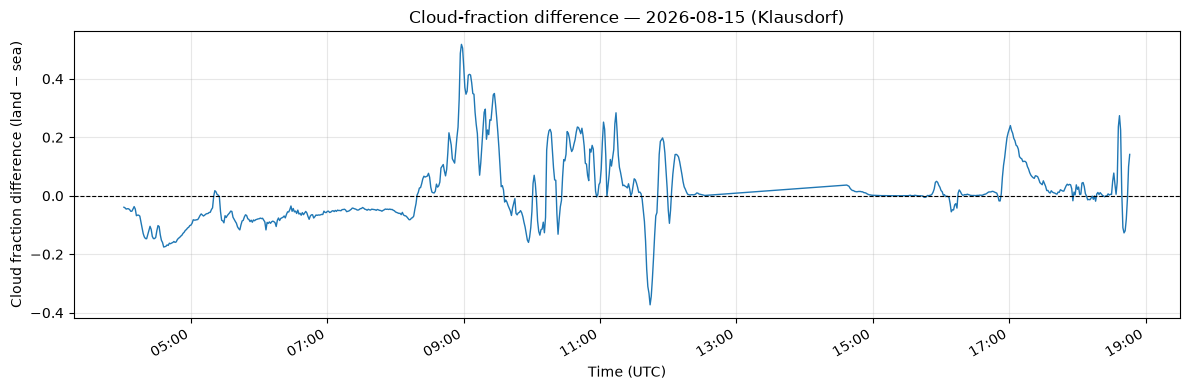

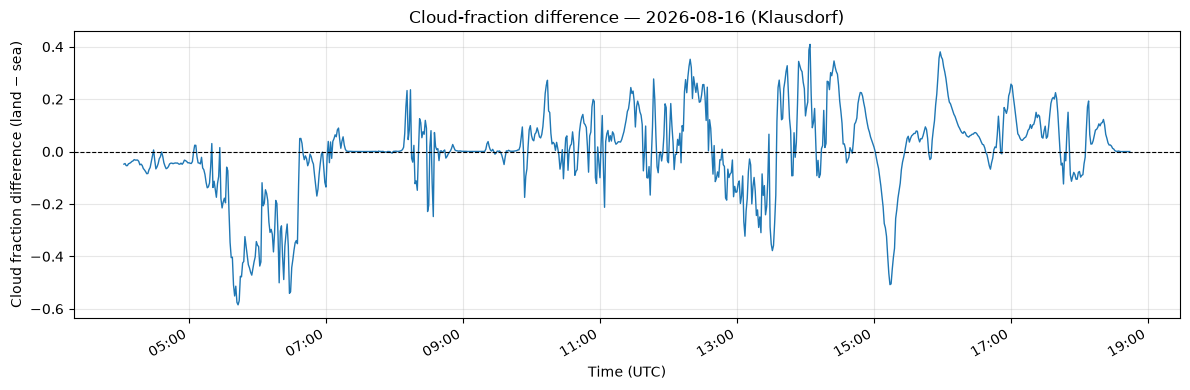

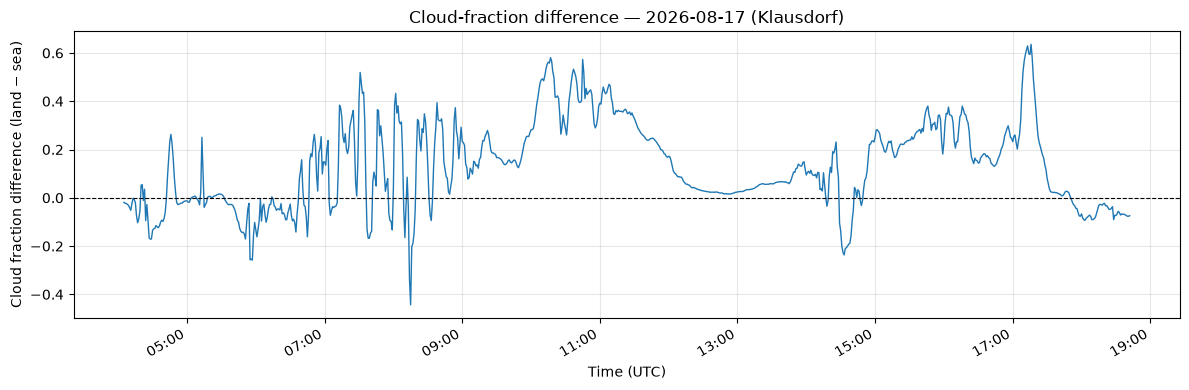

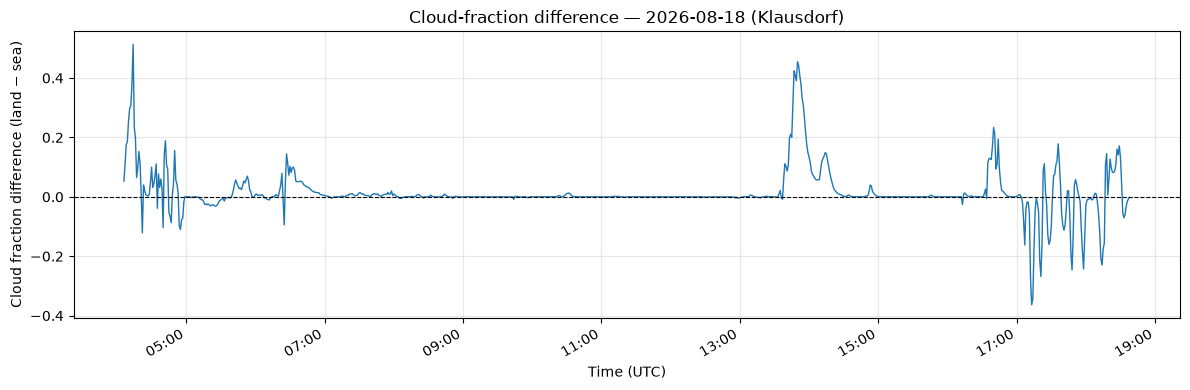

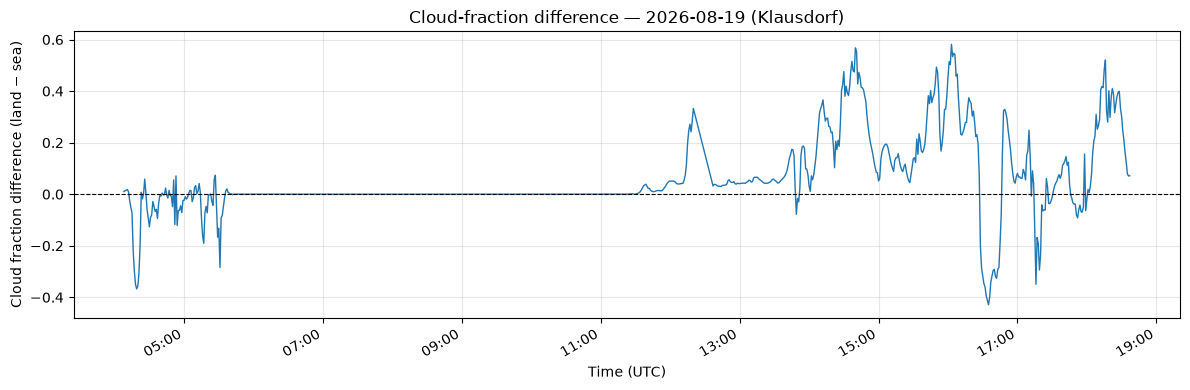

In [11]:
# plot cloud-fraction difference for each day
for date in dates2:
    day_start = pd.Timestamp(date, tz="UTC")
    day_end = day_start + pd.Timedelta(days=1)
    day_data = cf2.loc[
        (cf2["timestamp_utc"] >= day_start)
        & (cf2["timestamp_utc"] < day_end)
    ]

    if day_data.empty:
        print(f"No data available for {date}")
        continue

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(
        day_data["timestamp_utc"],
        day_data["cloud_fraction_diff"],
        linewidth=1,
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Cloud-fraction difference — {date} (Klausdorf)")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Cloud fraction difference (land − sea)")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

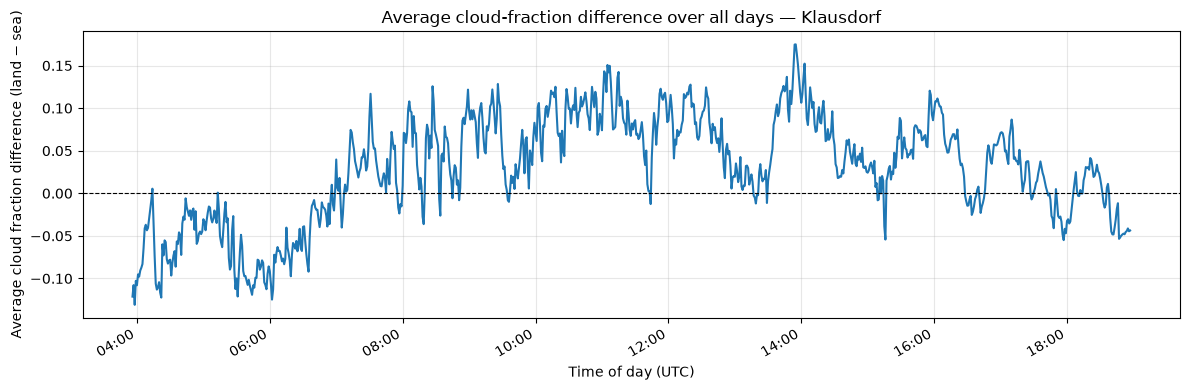

In [12]:
# average cloud-fraction difference over all days by time of day
cf2["time_of_day_seconds"] = (
    cf2["timestamp_utc"].dt.hour * 3600
    + cf2["timestamp_utc"].dt.minute * 60
    + cf2["timestamp_utc"].dt.second
)

average_diff2 = (
    cf2.groupby("time_of_day_seconds", as_index=False)["cloud_fraction_diff"]
    .mean()
    .rename(columns={"cloud_fraction_diff": "average_cloud_fraction_diff"})
)
average_diff2["time_utc"] = (
    pd.Timestamp("2000-01-01", tz="UTC")
    + pd.to_timedelta(average_diff2["time_of_day_seconds"], unit="s")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    average_diff2["time_utc"],
    average_diff2["average_cloud_fraction_diff"],
    linewidth=1.5,
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Average cloud-fraction difference over all days — Klausdorf")
ax.set_xlabel("Time of day (UTC)")
ax.set_ylabel("Average cloud fraction difference (land − sea)")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


In [10]:
# all data
cf4 = pd.read_csv(processed_data_path + "CAM4/combined_cloud_fraction_timeseries.csv")

In [11]:
cf4.timestamp_utc = pd.to_datetime(cf4.timestamp_utc)
print(cf4.timestamp_utc.dtype)

datetime64[us, UTC]


In [12]:
cf4.cloud_fraction_land = cf4.cloud_fraction_total
print(cf4.cloud_fraction_total, cf4.cloud_fraction_land)

0       0.8480
1       0.8862
2       0.8980
3       0.9150
4       0.9228
         ...  
9768    0.9142
9769    0.9457
9770    0.9531
9771    0.9432
9772    0.9246
Name: cloud_fraction_total, Length: 9773, dtype: float64 0       0.8480
1       0.8862
2       0.8980
3       0.9150
4       0.9228
         ...  
9768    0.9142
9769    0.9457
9770    0.9531
9771    0.9432
9772    0.9246
Name: cloud_fraction_land, Length: 9773, dtype: float64


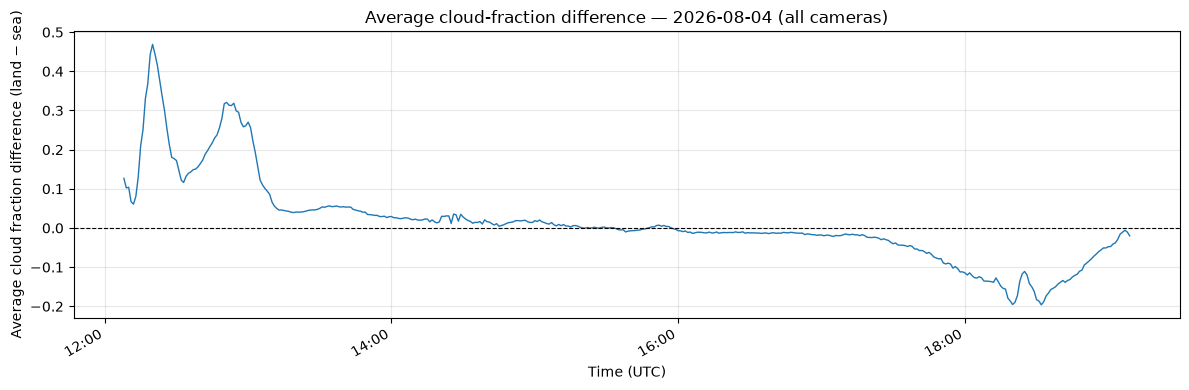

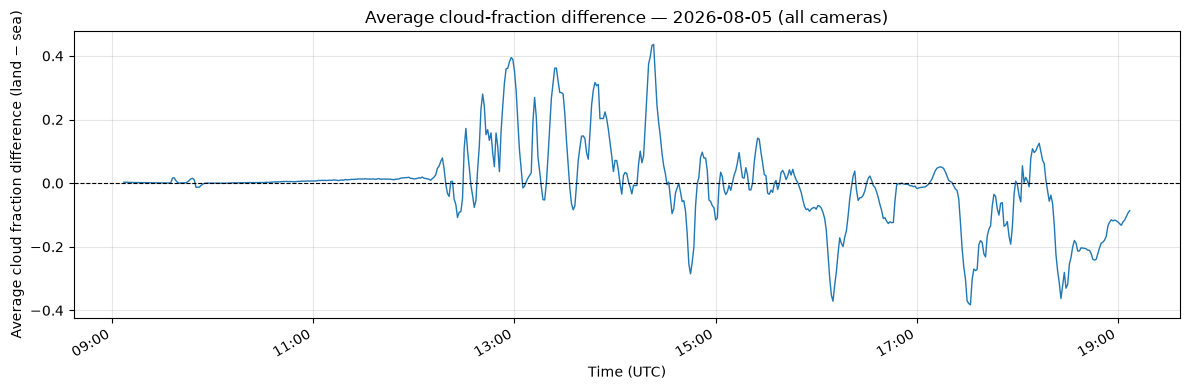

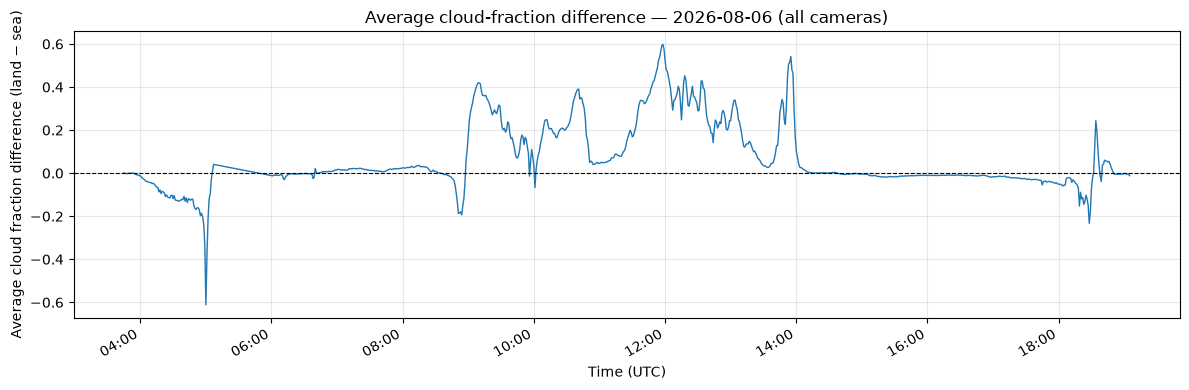

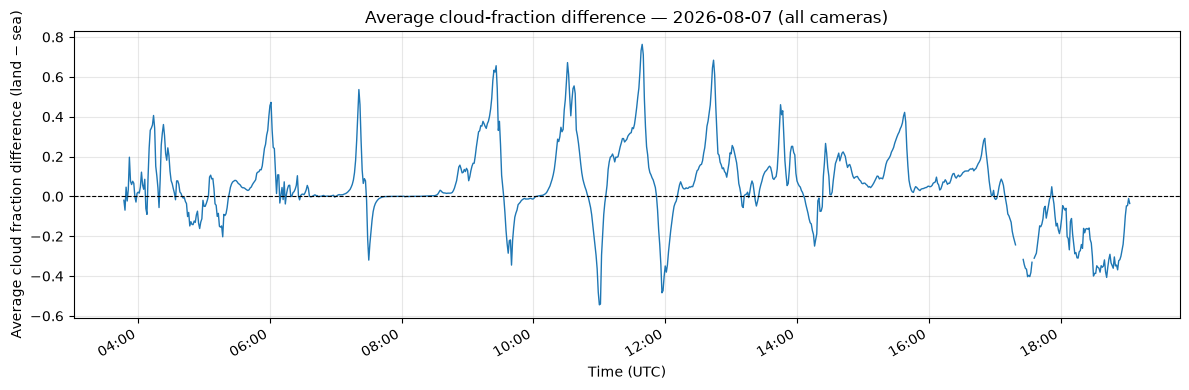

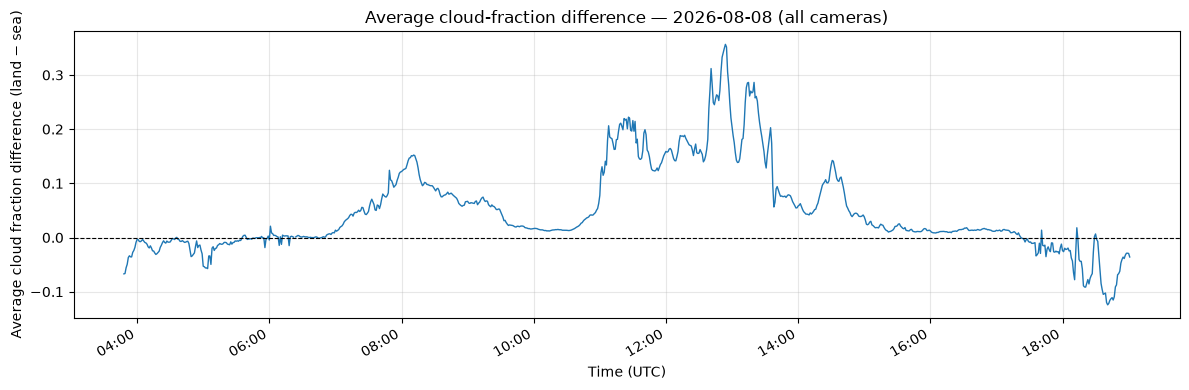

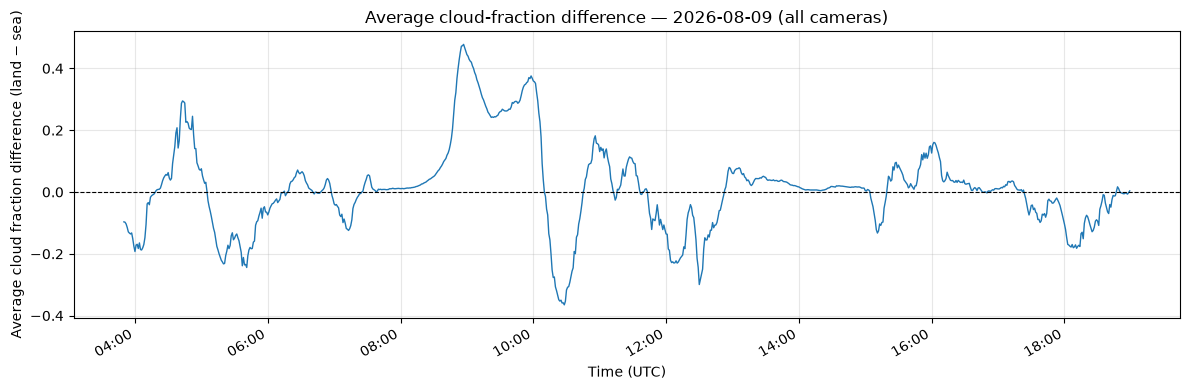

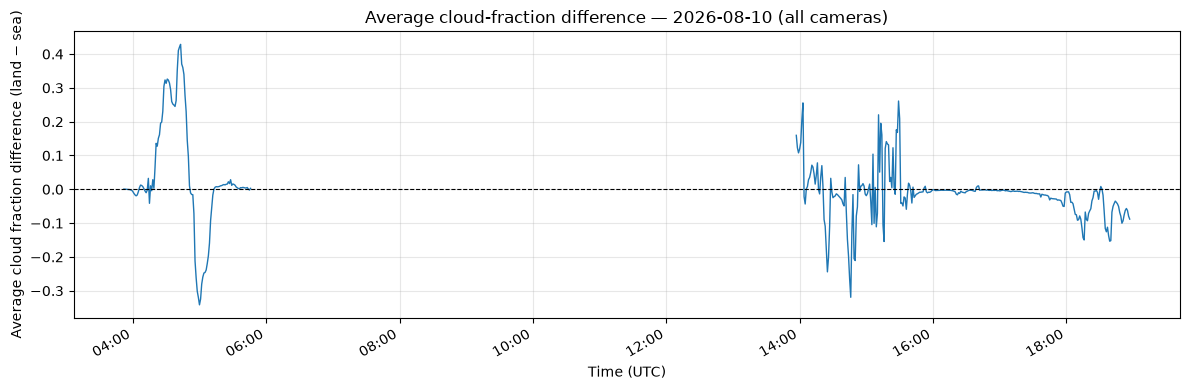

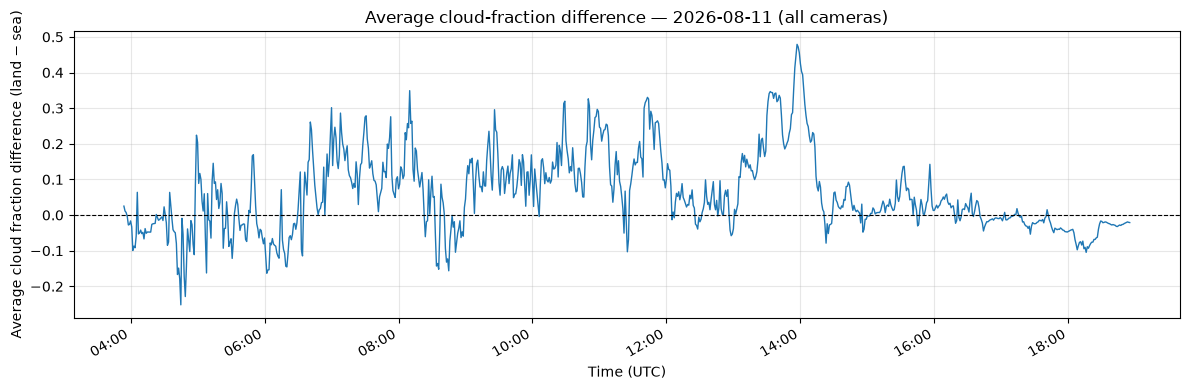

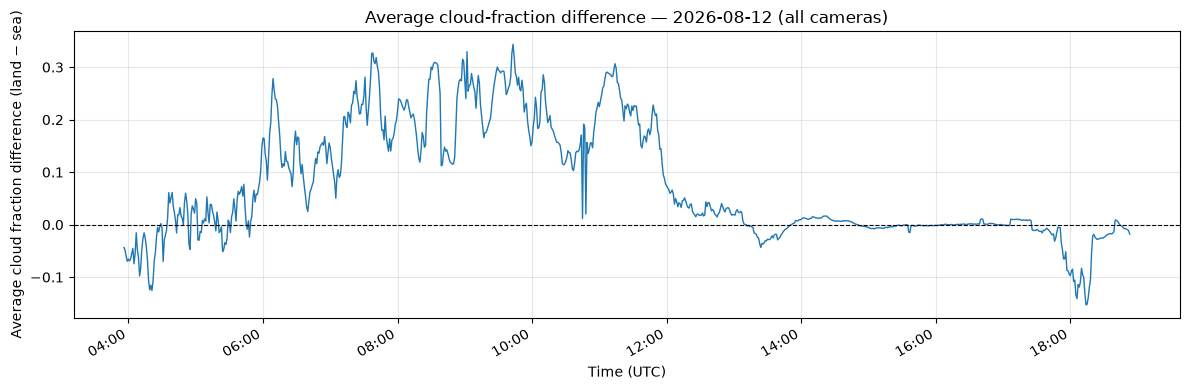

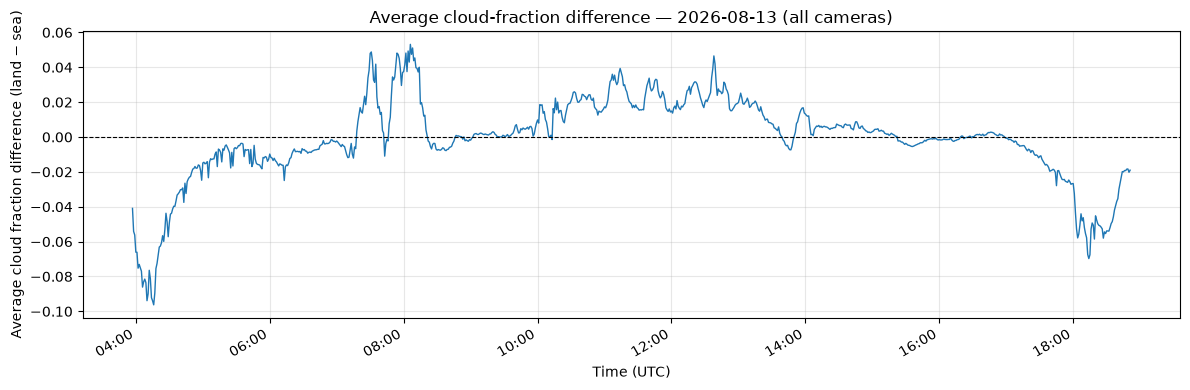

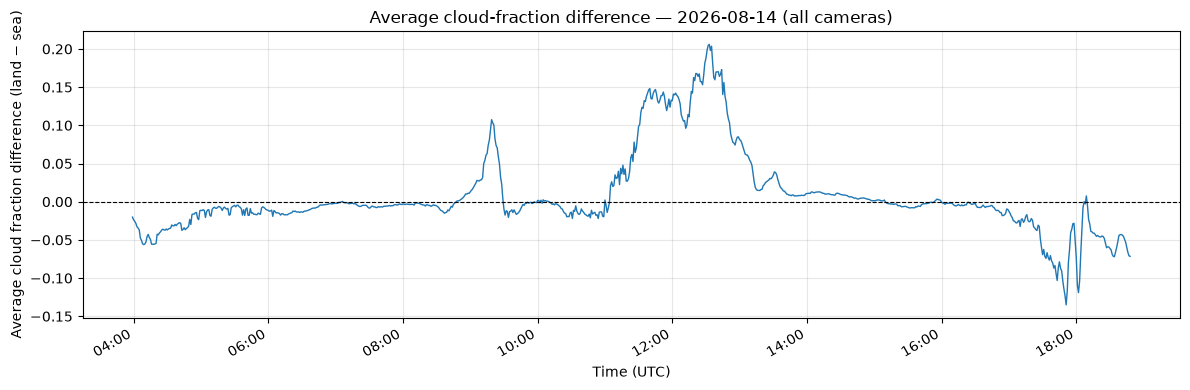

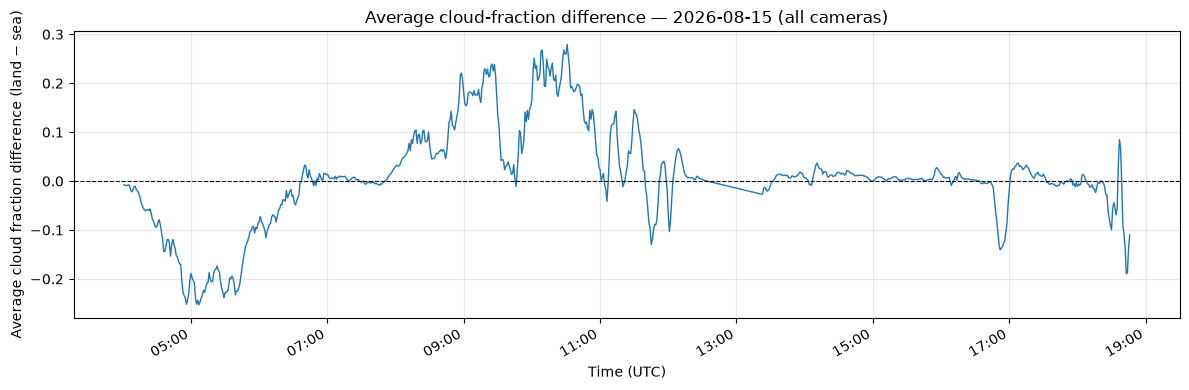

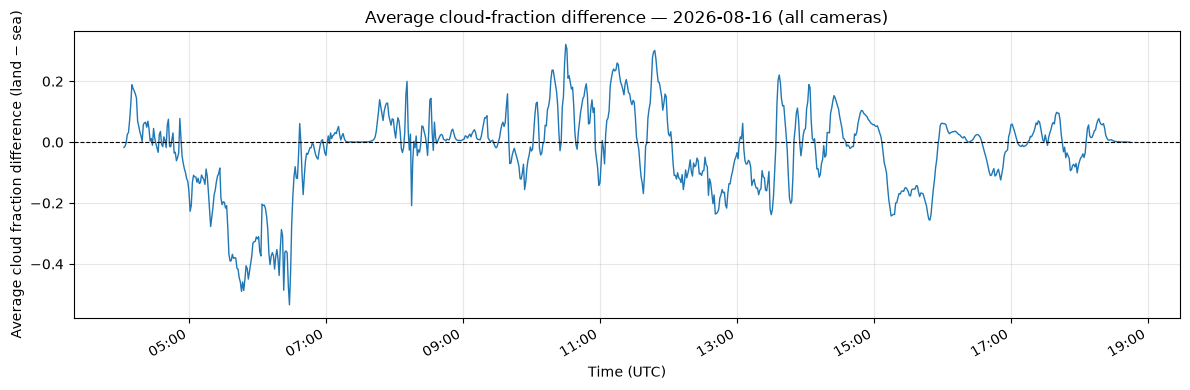

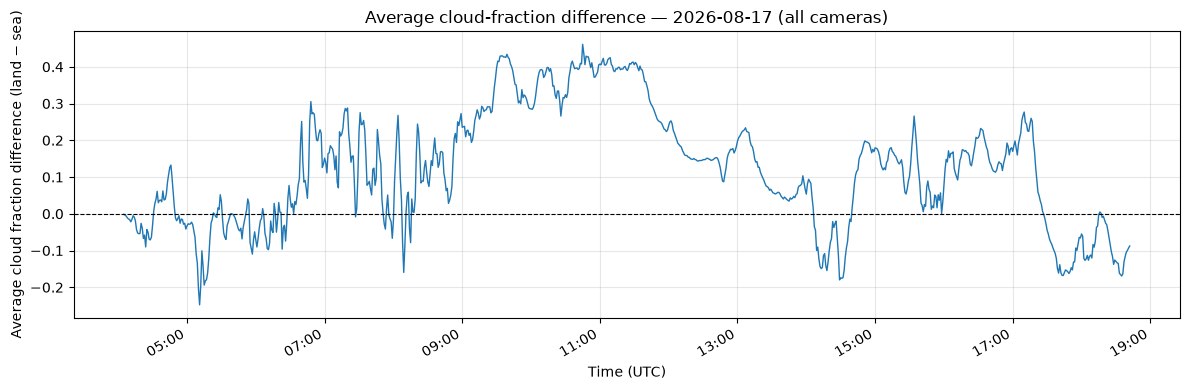

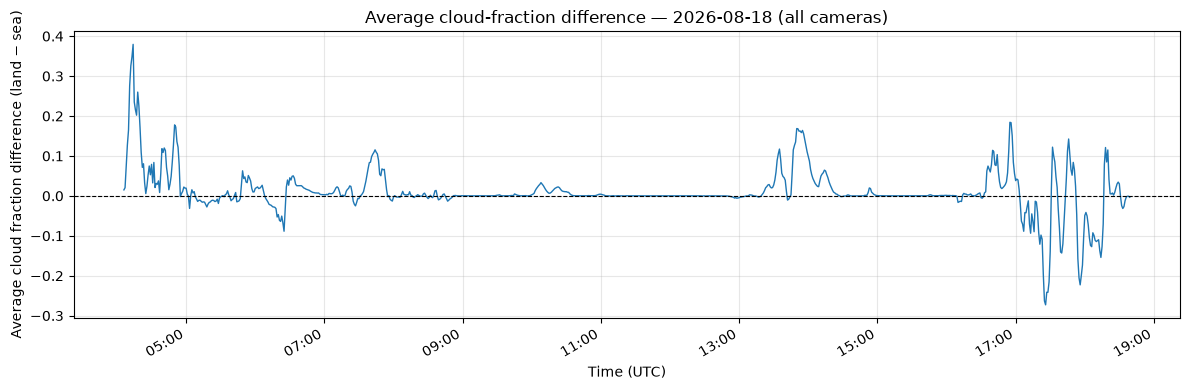

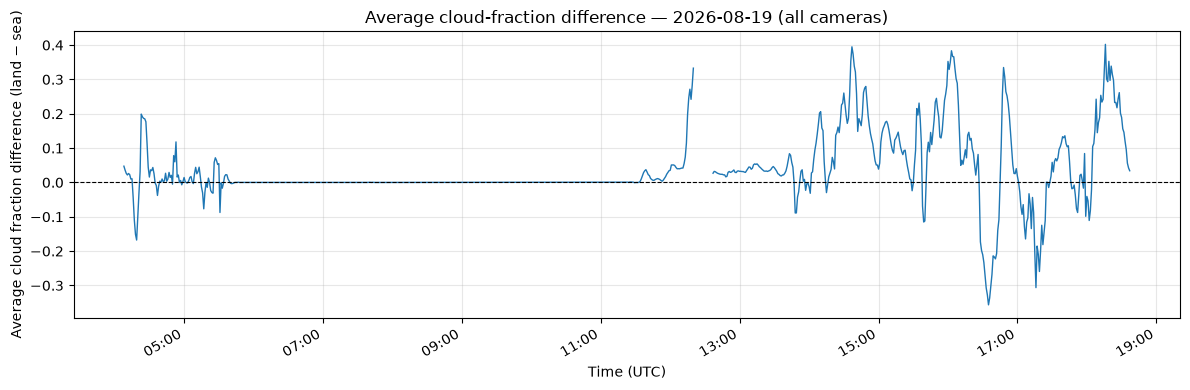

In [13]:
# combine all cloud cameras
cf_all = pd.concat(
    [
        cf[["camera", "timestamp_utc", "cloud_fraction_land", "cloud_fraction_sea"]],
        cf2[["camera", "timestamp_utc", "cloud_fraction_land", "cloud_fraction_sea"]],
        cf4[["camera", "timestamp_utc", "cloud_fraction_land", "cloud_fraction_sea"]],
    ],
    ignore_index=True,
)

# Average land over CAM1, CAM2, and CAM4. CAM4 has no sea view, so average
# sea only over CAM1 and CAM2. Groupby.mean() ignores missing values.
land_by_timestep = (
    cf_all.groupby("timestamp_utc")["cloud_fraction_land"]
    .mean()
    .rename("cloud_fraction_land")
)
sea_by_timestep = (
    cf_all[cf_all["camera"].isin(["CAM1", "CAM2"])]
    .groupby("timestamp_utc")["cloud_fraction_sea"]
    .mean()
    .rename("cloud_fraction_sea")
)
cf_all = pd.concat([land_by_timestep, sea_by_timestep], axis=1).sort_index().reset_index()
cf_all["cloud_fraction_diff"] = (
    cf_all["cloud_fraction_land"] - cf_all["cloud_fraction_sea"]
)

# Plot the combined-camera difference for every day represented in cf_all.
all_dates = sorted(cf_all["timestamp_utc"].dt.strftime("%Y-%m-%d").unique())
for date in all_dates:
    day_start = pd.Timestamp(date, tz="UTC")
    day_end = day_start + pd.Timedelta(days=1)
    day_data = cf_all.loc[
        (cf_all["timestamp_utc"] >= day_start)
        & (cf_all["timestamp_utc"] < day_end)
    ]

    if day_data["cloud_fraction_diff"].dropna().empty:
        print(f"No land/sea difference data available for {date}")
        continue

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(
        day_data["timestamp_utc"],
        day_data["cloud_fraction_diff"],
        linewidth=1,
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Average cloud-fraction difference — {date} (all cameras)")
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Average cloud fraction difference (land − sea)")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

# Average the combined-camera time series over all days by time of day.
cf_all["time_of_day_seconds"] = (
    cf_all["timestamp_utc"].dt.hour * 3600
    + cf_all["timestamp_utc"].dt.minute * 60
    + cf_all["timestamp_utc"].dt.second
)
average_diff_all = (
    cf_all.dropna(subset=["cloud_fraction_diff"])
    .groupby("time_of_day_seconds", as_index=False)["cloud_fraction_diff"]
    .mean()
    .rename(columns={"cloud_fraction_diff": "average_cloud_fraction_diff"})
)
average_diff_all["time_utc"] = (
    pd.Timestamp("2000-01-01", tz="UTC")
    + pd.to_timedelta(average_diff_all["time_of_day_seconds"], unit="s")
)


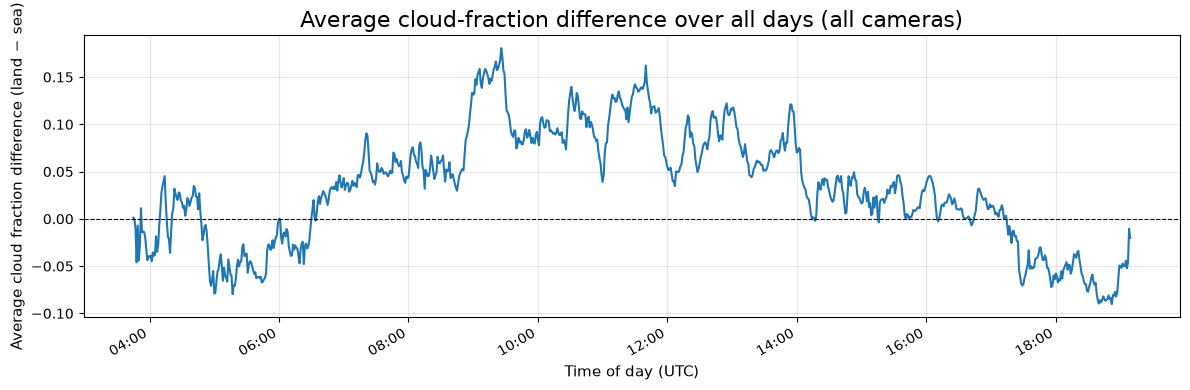

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    average_diff_all["time_utc"],
    average_diff_all["average_cloud_fraction_diff"],
    linewidth=1.5,
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Average cloud-fraction difference over all days (all cameras)", fontsize=16)
ax.set_xlabel("Time of day (UTC)", fontsize=11)
ax.set_ylabel("Average cloud fraction difference (land − sea)", fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


n = 925, R² = 0.723
Quadratic coefficient = -0.00286785 (SE = 5.92252e-05, t = -48.423, p = 1.68e-255)
Linear-vs-quadratic F-test: F = 2344.760, p = 1.68e-255
Estimated maximum at 11.13:00 UTC (inside the observed time range)
Conclusion: the quadratic term is statistically significant and supports an inverted-U pattern (morning increase, afternoon decrease) at α = 0.05.


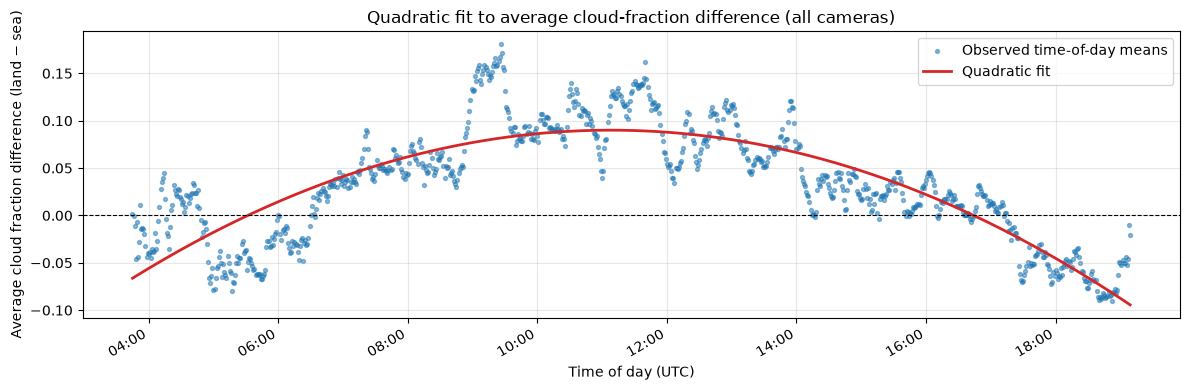

In [17]:
# Test whether the all-camera diurnal curve has a significant inverted-U shape.
# The p-values below describe the fit to the time-of-day means; they do not
# account for temporal autocorrelation or variation between individual days.
import numpy as np
from scipy import stats

fit_data = average_diff_all.dropna(subset=["time_of_day_seconds", "average_cloud_fraction_diff"]).copy()

# Center time at noon so the linear and quadratic coefficients are well scaled.
fit_data["time_hours"] = fit_data["time_of_day_seconds"] / 3600 - 12
x = fit_data["time_hours"].to_numpy()
y = fit_data["average_cloud_fraction_diff"].to_numpy()

# Compare a linear model with a quadratic model using least squares.
X_linear = np.column_stack([np.ones_like(x), x])
X_quadratic = np.column_stack([X_linear, x**2])
linear_coefficients, _, _, _ = np.linalg.lstsq(X_linear, y, rcond=None)
quadratic_coefficients, _, _, _ = np.linalg.lstsq(X_quadratic, y, rcond=None)

residuals_linear = y - X_linear @ linear_coefficients
residuals_quadratic = y - X_quadratic @ quadratic_coefficients
n = len(y)
df_quadratic = n - X_quadratic.shape[1]
ss_linear = np.sum(residuals_linear**2)
ss_quadratic = np.sum(residuals_quadratic**2)

# Standard errors and two-sided t-test for the quadratic coefficient.
residual_variance = ss_quadratic / df_quadratic
covariance = residual_variance * np.linalg.inv(X_quadratic.T @ X_quadratic)
standard_errors = np.sqrt(np.diag(covariance))
t_statistics = quadratic_coefficients / standard_errors
p_values = 2 * stats.t.sf(np.abs(t_statistics), df=df_quadratic)

# Nested-model F-test: does adding x^2 significantly improve the fit?
f_statistic = ((ss_linear - ss_quadratic) / 1) / (ss_quadratic / df_quadratic)
f_p_value = stats.f.sf(f_statistic, 1, df_quadratic)

quadratic_term = quadratic_coefficients[2]
quadratic_significant = p_values[2] < 0.05
inverted_u = quadratic_significant and quadratic_term < 0
vertex_hours = -quadratic_coefficients[1] / (2 * quadratic_term)
vertex_in_data = x.min() <= vertex_hours <= x.max()
r_squared = 1 - ss_quadratic / np.sum((y - y.mean()) ** 2)

print(f"n = {n}, R² = {r_squared:.3f}")
print(f"Quadratic coefficient = {quadratic_term:.6g} "
      f"(SE = {standard_errors[2]:.6g}, t = {t_statistics[2]:.3f}, "
      f"p = {p_values[2]:.3g})")
print(f"Linear-vs-quadratic F-test: F = {f_statistic:.3f}, p = {f_p_value:.3g}")
print(f"Estimated maximum at {vertex_hours + 12:.2f}:00 UTC "
      f"({'inside' if vertex_in_data else 'outside'} the observed time range)")

if inverted_u and vertex_in_data:
    print("Conclusion: the quadratic term is statistically significant and supports "
          "an inverted-U pattern (morning increase, afternoon decrease) at α = 0.05.")
else:
    print("Conclusion: the data do not provide statistically significant evidence for "
          "an inverted-U pattern at α = 0.05.")

# Visualize the fitted quadratic together with the observed time-of-day means.
x_fit = np.linspace(x.min(), x.max(), 400)
y_fit = np.column_stack([np.ones_like(x_fit), x_fit, x_fit**2]) @ quadratic_coefficients
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(fit_data["time_utc"], y, s=8, alpha=0.5, label="Observed time-of-day means")
ax.plot(
    pd.Timestamp("2000-01-01", tz="UTC") + pd.to_timedelta(x_fit + 12, unit="h"),
    y_fit,
    color="tab:red",
    linewidth=2,
    label="Quadratic fit",
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Quadratic fit to average cloud-fraction difference (all cameras)")
ax.set_xlabel("Time of day (UTC)")
ax.set_ylabel("Average cloud fraction difference (land − sea)")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()